In [11]:
import zipfile

with zipfile.ZipFile('/content/Brain.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/Brain')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [12]:
import os

print(os.listdir('/content/Brain'))

['Testing', 'Training']


In [13]:
print(os.listdir("/content/Brain/Testing"))


['glioma', 'notumor', 'pituitary', 'meningioma']


In [14]:
print(os.listdir("/content/Brain/Testing/glioma"))


['Te-gl_342.jpg', 'Te-gl_389.jpg', 'Te-gl_380.jpg', 'Te-gl_38.jpg', 'Te-gl_201.jpg', 'Te-gl_316.jpg', 'Te-gl_398.jpg', 'Te-gl_385.jpg', 'Te-gl_122.jpg', 'Te-gl_359.jpg', 'Te-gl_29.jpg', 'Te-gl_248.jpg', 'Te-gl_203.jpg', 'Te-gl_23.jpg', 'Te-gl_370.jpg', 'Te-gl_158.jpg', 'Te-gl_332.jpg', 'Te-gl_329.jpg', 'Te-gl_168.jpg', 'Te-gl_272.jpg', 'Te-gl_320.jpg', 'Te-gl_317.jpg', 'Te-gl_188.jpg', 'Te-gl_148.jpg', 'Te-gl_91.jpg', 'Te-gl_90.jpg', 'Te-gl_166.jpg', 'Te-gl_28.jpg', 'Te-gl_116.jpg', 'Te-gl_384.jpg', 'Te-gl_120.jpg', 'Te-gl_83.jpg', 'Te-gl_99.jpg', 'Te-gl_33.jpg', 'Te-gl_307.jpg', 'Te-gl_242.jpg', 'Te-gl_204.jpg', 'Te-gl_345.jpg', 'Te-gl_310.jpg', 'Te-gl_124.jpg', 'Te-gl_165.jpg', 'Te-gl_279.jpg', 'Te-gl_344.jpg', 'Te-gl_9.jpg', 'Te-gl_59.jpg', 'Te-gl_232.jpg', 'Te-gl_93.jpg', 'Te-gl_136.jpg', 'Te-gl_177.jpg', 'Te-gl_96.jpg', 'Te-gl_365.jpg', 'Te-gl_294.jpg', 'Te-gl_357.jpg', 'Te-gl_399.jpg', 'Te-gl_349.jpg', 'Te-gl_81.jpg', 'Te-gl_299.jpg', 'Te-gl_393.jpg', 'Te-gl_62.jpg', 'Te-gl_132.j

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
# SET YOUR DATASET PATH HERE
DATASET_PATH = "/content/Brain"

TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
TEST_PATH  = os.path.join(DATASET_PATH, "Testing")

# Parameters
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 20
NUM_CLASSES = 4
LR          = 0.0001

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print("Train path:", TRAIN_PATH)
print("Test path :", TEST_PATH)
print("Classes   :", CLASS_NAMES)

Train path: /content/Brain/Training
Test path : /content/Brain/Testing
Classes   : ['glioma', 'meningioma', 'notumor', 'pituitary']


In [11]:

# DATA GENERATORS
# Training data — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

# Testing data — only rescale, no augmentation
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# TRAINING GENERATOR
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)


# VALIDATION GENERATOR
val_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)


# TEST GENERATOR

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


# DISPLAY DATASET INFORMATION

print("\nTraining samples  :", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Testing samples   :", test_generator.samples)
print("Class indices     :", train_generator.class_indices)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Training samples  : 4480
Validation samples: 1120
Testing samples   : 1600
Class indices     : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [12]:
#model-building
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
print(model)



<Sequential name=sequential_1, built=True>


In [15]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 90s 533ms/step - accuracy: 0.8366 - loss: 0.4521 - val_accuracy: 0.8857 - val_loss: 0.3195
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 479ms/step - accuracy: 0.8904 - loss: 0.2929 - val_accuracy: 0.8991 - val_loss: 0.2813
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 69s 490ms/step - accuracy: 0.9033 - loss: 0.2639 - val_accuracy: 0.8920 - val_loss: 0.2828
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 475ms/step - accuracy: 0.9150 - loss: 0.2199 - val_accuracy: 0.9098 - val_loss: 0.2494
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 478ms/step - accuracy: 0.9141 - loss: 0.2206 - val_accuracy: 0.8929 - val_loss: 0.2929
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 68s 485ms/step - accuracy: 0.9221 - loss: 0.2059 - val_accuracy: 0.9170 - val_loss: 0.2297
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 533ms/step - accuracy: 0.9366 - loss: 0.1721 - val_accuracy: 0.9134 - val_loss: 0.2364
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 479ms/step - accuracy: 0.9377 - loss: 0

In [16]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8569 - loss: 0.7155
Test Loss: 0.715511679649353
Test Accuracy: 0.8568750023841858


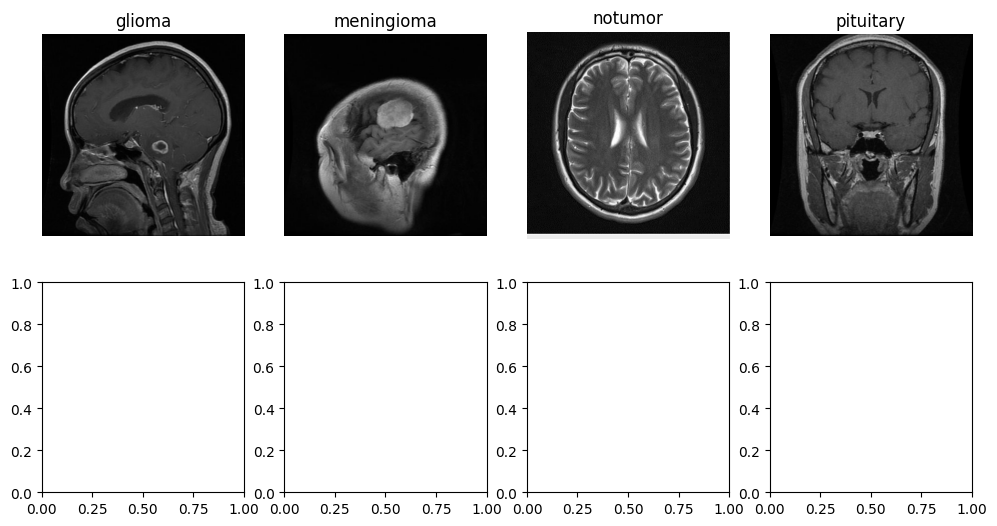

In [17]:
# Show sample images
fig, axes = plt.subplots(2, 4, figsize=(12,6))

for i, class_name in enumerate(CLASS_NAMES):

    class_path = os.path.join(TRAIN_PATH, class_name)

    img_name = os.listdir(class_path)[0]

    img_path = os.path.join(class_path, img_name)

    img = plt.imread(img_path)

    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(class_name)
    axes[0, i].axis('off')

plt.show()

In [18]:
#TRANSFER LEARNING WITH VGG16

#Load pretrained VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print("VGG16 Base Model Summary:")
print(f"Total layers in VGG16: {len(base_model.layers)}")

#FREEZE base model layers (don't train them)
base_model.trainable = False

frozen_count = sum(1 for layer in base_model.layers if not layer.trainable)
print(f"Frozen layers: {frozen_count}")

#Add custom top layers for brain tumor classification
model = keras.Sequential([
    # Pretrained VGG16 base
    base_model,

    # Flatten
    layers.GlobalAveragePooling2D(),

    # Dense layers (our custom classifier)
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Output layer — 4 classes
    layers.Dense(NUM_CLASSES, activation='softmax')
])

#Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\nTotal parameters    : {model.count_params():,}")
print(f"Trainable parameters: {sum(tf.size(w).numpy() for w in model.trainable_weights):,}")

VGG16 Base Model Summary:
Total layers in VGG16: 19
Frozen layers: 19


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,112,772 (57.65 MB)

 Trainable params: 396,548 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)


Total parameters    : 15,112,772
Trainable parameters: 396,548


In [20]:

# MULTIPLE IMAGE PREDICTION (ONLY 10 IMAGES)
from tensorflow.keras.preprocessing import image

folder = "/content/Brain/Testing/glioma"

count = 0

for img_name in os.listdir(folder):

    if count == 10:   # stop after 10 images
        break

    img_path = os.path.join(folder, img_name)

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = CLASS_NAMES[np.argmax(prediction)]

    print(img_name, "→", predicted_class)

    count += 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Te-gl_342.jpg → notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Te-gl_389.jpg → notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Te-gl_380.jpg → notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Te-gl_38.jpg → notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Te-gl_201.jpg → notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Te-gl_316.jpg → notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Te-gl_398.jpg → notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Te-gl_385.jpg → notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Te-gl_122.jpg → notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Te-gl_359.jpg → notumor


In [21]:
#TEST ACCURACY
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 198ms/step - accuracy: 0.2500 - loss: 1.3969
Test Accuracy: 0.25


In [22]:
model.evaluate(test_generator)

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.2500 - loss: 1.3969


[1.3968687057495117, 0.25]

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step


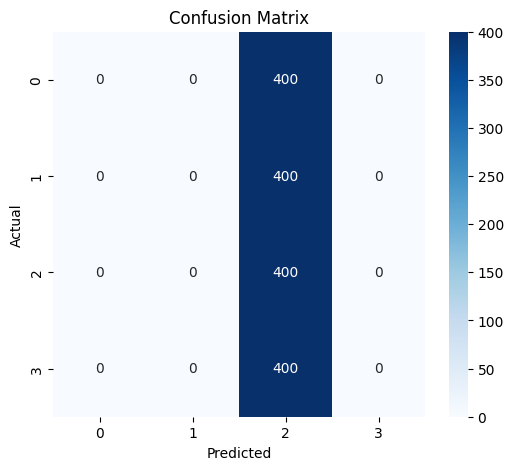

In [24]:
from sklearn.metrics import confusion_matrix
pred = model.predict(test_generator)
y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(test_generator.classes, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

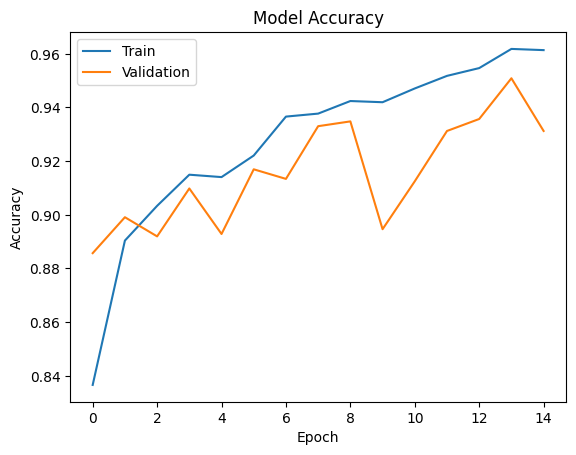

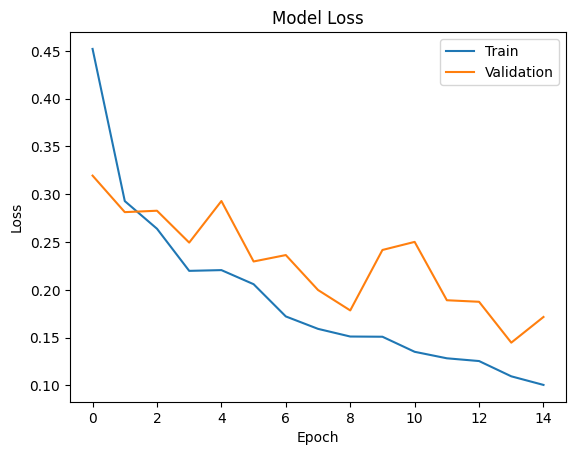

In [26]:
# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.show()

In [27]:
#CLASSIFICATION REPORT
from sklearn.metrics import classification_report

print(classification_report(
    test_generator.classes,
    y_pred,
    target_names=CLASS_NAMES
))

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       400
  meningioma       0.00      0.00      0.00       400
     notumor       0.25      1.00      0.40       400
   pituitary       0.00      0.00      0.00       400

    accuracy                           0.25      1600
   macro avg       0.06      0.25      0.10      1600
weighted avg       0.06      0.25      0.10      1600

